# Lab: Supervised Machine Learning for Time Series (Student Version)

Based on Lecture 3, this lab will guide you through the paradigm shift from classical statistical models to supervised machine learning models for time series forecasting.

**Learning Objectives:**
1. Transform a raw time series into a tabular format.
2. Engineer advanced features (Time Embeddings, Lags, Rolling Windows).
3. Perform chronological validation to prevent target leakage.
4. Train a tree-based model (XGBoost/Random Forest) and observe the extrapolation problem.
5. Implement a Direct Multi-Step Forecasting strategy.

**Dataset:** BTC-USD 1-Minute Data

In [1]:
# Run this cell to install necessary libraries if you haven't already
!pip install kagglehub xgboost scikit-learn pandas matplotlib

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# Download the BTC dataset
path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data", output_dir="btc_data")
print("Path to dataset ready at:", path)
data_path = path + "/BTCUSD_1m_Binance.csv" # Note: you may need to adjust the exact filename based on the extracted contents

100%|██████████| 0.98G/0.98G [00:11<00:00, 92.3MB/s]

Extracting files...


Path to dataset ready at: btc_data


## Task 1: Load and Resample the Data
The 1-minute dataset is massive. To make our feature engineering and model training efficient, we need to resample this data to a **Daily** frequency.

1. Load the CSV using pandas.
2. Convert the timestamp column to a `datetime` object and set it as the index.
3. Resample the data to daily frequency (`'D'`). Use `.last()` for the 'Close' price, and `.sum()` for 'Volume'. For this lab, we will primarily focus on predicting the daily **Close** price.

In [3]:
# YOUR CODE HERE
df = pd.read_csv(data_path)
print(df.head())
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['Close time'])
# Set timestamp as index
df.set_index('timestamp', inplace=True)
# Resample to daily data
daily_df = df.resample('D').agg({
    'Close': 'last',
    'Volume': 'sum'
})
print(daily_df.head())

             Open time     Open     High      Low    Close    Volume  \
0  2017-08-17 04:00:00  4261.48  4261.48  4261.48  4261.48  1.775183   
1  2017-08-17 04:01:00  4261.48  4261.48  4261.48  4261.48  0.000000   
2  2017-08-17 04:02:00  4280.56  4280.56  4280.56  4280.56  0.261074   
3  2017-08-17 04:03:00  4261.48  4261.48  4261.48  4261.48  0.012008   
4  2017-08-17 04:04:00  4261.48  4261.48  4261.48  4261.48  0.140796   

                Close time  Quote asset volume  Number of trades  \
0  2017-08-17 04:00:59.999         7564.906851               3.0   
1  2017-08-17 04:01:59.999            0.000000               0.0   
2  2017-08-17 04:02:59.999         1117.542921               2.0   
3  2017-08-17 04:03:59.999           51.171852               3.0   
4  2017-08-17 04:04:59.999          599.999338               1.0   

   Taker buy base asset volume  Taker buy quote asset volume  Ignore  
0                     0.075183                    320.390851     0.0  
1               

### Data Pre-processing part Done ✅✅

## Task 2: Advanced Feature Engineering (Time Embeddings)
Machine learning models don't inherently understand dates. We must extract temporal features so the model can learn seasonality (e.g., "Is it the weekend?", "What month is it?").

Create the following columns in `df_daily`:
- `day_of_week`
- `month`
- `day_of_year`
- `is_weekend` (1 if Saturday/Sunday, 0 otherwise)

In [4]:
# YOUR CODE HERE
daily_df["day_of_week"] = daily_df.index.dayofweek
daily_df["month"] = daily_df.index.month
daily_df["day_of_year"] = daily_df.index.dayofyear
daily_df["is_weekend"] = daily_df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)
print(daily_df.head())

              Close       Volume  day_of_week  month  day_of_year  is_weekend
timestamp                                                                    
2017-08-17  4285.08   795.150377            3      8          229           0
2017-08-18  4108.37  1199.888264            4      8          230           0
2017-08-19  4139.98   381.309763            5      8          231           1
2017-08-20  4086.29   467.083022            6      8          232           1
2017-08-21  4016.00   691.743060            0      8          233           0


## Task 3: Advanced Feature Engineering (Lags and Rolling Windows)
To capture autoregressive patterns, we need to give the model historical context for the current row. 

Create the following features based on the `Close` price:
1. **Lags**: `lag_1`, `lag_3`, `lag_7` (Values from 1, 3, and 7 days ago).
2. **Rolling Windows**: `rolling_mean_7`, `rolling_std_7` (7-day moving average and standard deviation).

*Hint: Use `df.shift()` and `df.rolling()`.*
*Crucial step: Drop any rows containing NaN values generated by shifting!*

In [5]:
# YOUR CODE HERE
daily_df["lag_1"] = daily_df["Close"].shift(1)
daily_df["lag_3"] = daily_df["Close"].shift(3)
daily_df["lag_7"] = daily_df["Close"].shift(7)
daily_df["rolling_mean_7"] = daily_df["Close"].rolling(window=7).mean()
daily_df["rolling_std_7"] = daily_df["Close"].rolling(window=7).std()
#drop rows with NaN values created by lag and rolling features
daily_df.dropna(inplace=True)
print(daily_df.head(10))

              Close      Volume  day_of_week  month  day_of_year  is_weekend  \
timestamp                                                                      
2017-08-24  4316.01  787.418753            3      8          236           0   
2017-08-25  4280.68  573.612740            4      8          237           0   
2017-08-26  4337.44  228.108068            5      8          238           1   
2017-08-27  4310.01  350.692585            6      8          239           1   
2017-08-28  4386.69  603.841616            0      8          240           0   
2017-08-29  4587.48  603.545028            1      8          241           0   
2017-08-30  4555.14  808.468771            2      8          242           0   
2017-08-31  4724.89  556.956802            3      8          243           0   
2017-09-01  4834.91  560.666366            4      9          244           0   
2017-09-02  4472.14  929.148595            5      9          245           1   

              lag_1    lag_3    lag_7  

### Adding Sinsouidal Pattern to Data to track seasonallity

In [6]:
#Add sinsiodal features for seasonality
daily_df["dayofweek_sinsuidal"] = np.sin(2 * np.pi * daily_df["day_of_week"] / 7)
daily_df["month_sinsuidal"] = np.sin(2 * np.pi * daily_df["month"] / 12)
print(daily_df.head())

              Close      Volume  day_of_week  month  day_of_year  is_weekend  \
timestamp                                                                      
2017-08-24  4316.01  787.418753            3      8          236           0   
2017-08-25  4280.68  573.612740            4      8          237           0   
2017-08-26  4337.44  228.108068            5      8          238           1   
2017-08-27  4310.01  350.692585            6      8          239           1   
2017-08-28  4386.69  603.841616            0      8          240           0   

              lag_1    lag_3    lag_7  rolling_mean_7  rolling_std_7  \
timestamp                                                              
2017-08-24  4114.01  4016.00  4285.08     4117.237143      97.714881   
2017-08-25  4316.01  4040.00  4108.37     4141.852857     115.240759   
2017-08-26  4280.68  4114.01  4139.98     4170.061429     136.847454   
2017-08-27  4337.44  4316.01  4086.29     4202.021429     140.107823   
2017-08

## Task 4: Chronological Train/Test Split
**Danger of Target Leakage**: In time series, we cannot use random `train_test_split`. We must split chronologically to avoid using future data to predict the past.

1. Define your features (`X`) and your target variable (`y`, which is `Close`).
2. Split the data chronologically: the first 80% of rows for training, the last 20% for testing.

In [7]:
# YOUR CODE HERE
# Prepare Chronological train-test split for lagged features AND target variable
X = daily_df.drop(columns=["Close"])
y = daily_df["Close"]
split_index = int(len(daily_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
print(f"Training set size: {len(X_train)}, Testing set size: {len(X_test)}")

Training set size: 2376, Testing set size: 595


## Task 5: Train a Tree-Based Model (XGBoost or Random Forest)
Now that the data is tabular, train a supervised machine learning model.

1. Initialize an `XGBRegressor` or `RandomForestRegressor`.
2. Fit the model on `X_train` and `y_train`.
3. Make predictions on `X_test`.

In [8]:
# YOUR CODE HERE
from sklearn.ensemble import RandomForestRegressor
# Train Random Forest
rf_model = RandomForestRegressor(bootstrap=False)
rf_model.fit(X_train, y_train)

RandomForestRegressor(bootstrap=False)

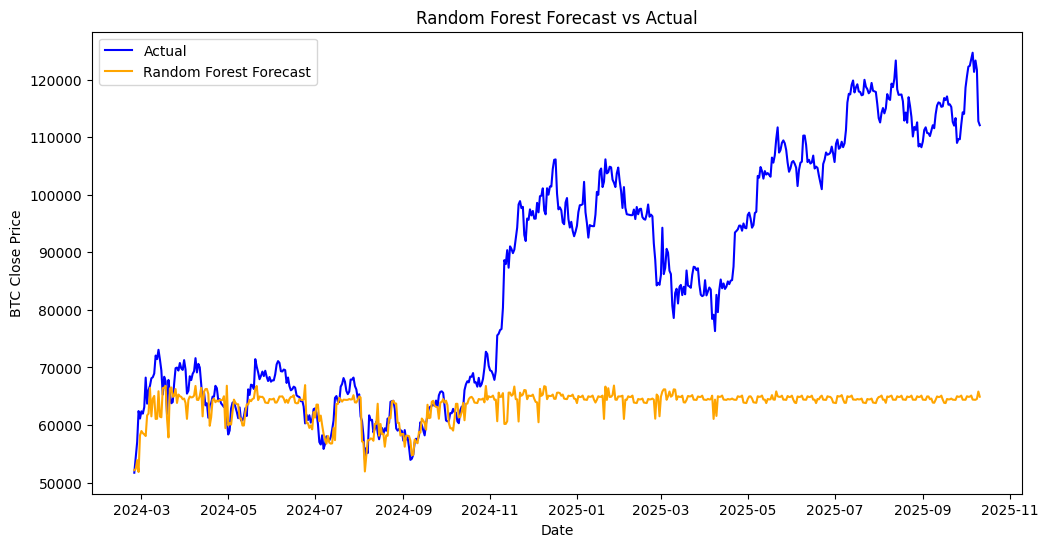

In [9]:
# plot forecast vs actual
y_pred_rf = rf_model.predict(X_test)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, y_pred_rf, label='Random Forest Forecast', color='orange')
plt.title('Random Forest Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('BTC Close Price')
plt.legend()
plt.show()

### it seem that this model suffer from Extrapolation problem so he fail to capture data behaveiour

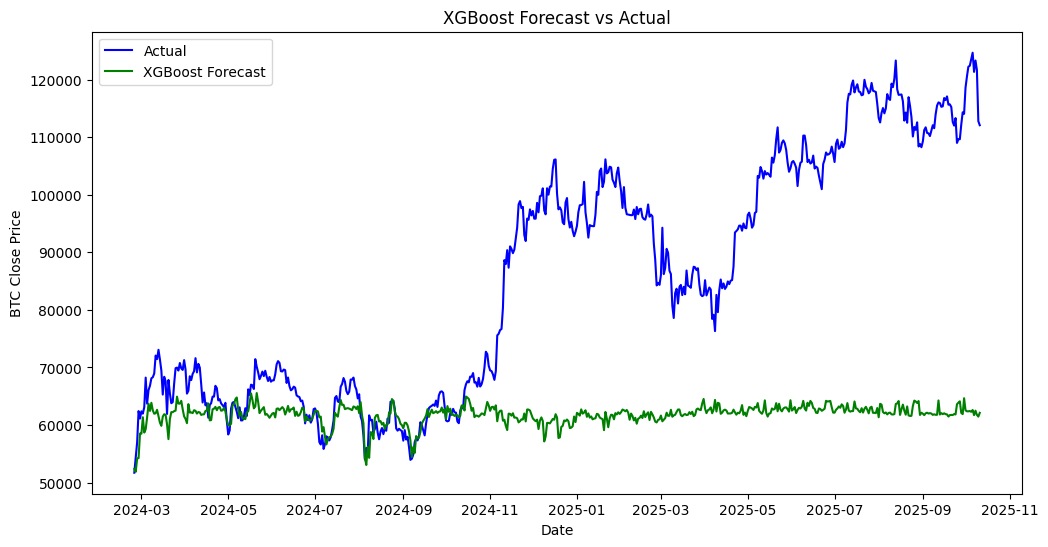

In [10]:
#try XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42,bootstrap=False)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, y_pred_xgb, label='XGBoost Forecast', color='green')
plt.title('XGBoost Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('BTC Close Price')
plt.legend()    

### Same Extrapolation problem here at `XGBoost`

### Solving Etrapolation problem

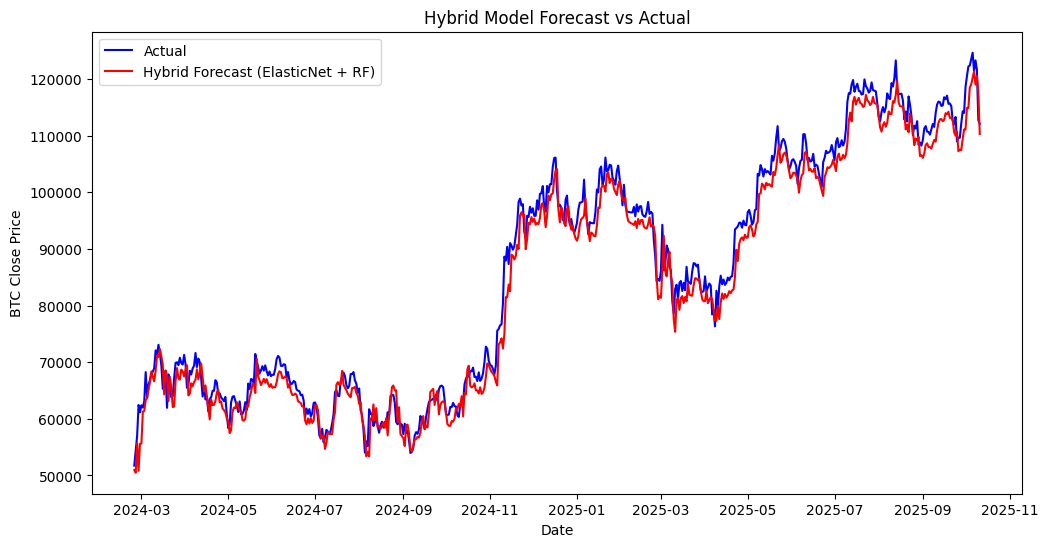

In [11]:
from sklearn.linear_model import ElasticNetCV
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Fit a linear model to capture the overall trend
trend_model = ElasticNetCV(cv=5)
trend_model.fit(X_train, y_train)

# 2. Extract the trend from the training data (Detrending)
trend_pred_train = trend_model.predict(X_train)
y_train_detrend = y_train - trend_pred_train

# 3. Train the Random Forest on the detrended residuals
rf_hybrid_model = RandomForestRegressor(bootstrap=False, random_state=42)
rf_hybrid_model.fit(X_train, y_train_detrend)

# 4. Predict on the test set by combining Trend + Tree Residuals
trend_pred_test = trend_model.predict(X_test)
rf_residual_pred = rf_hybrid_model.predict(X_test)

y_pred_hybrid = trend_pred_test + rf_residual_pred

# 5. Plot the hybrid model results
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, y_pred_hybrid, label='Hybrid Forecast (ElasticNet + RF)', color='red')
plt.title('Hybrid Model Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('BTC Close Price')
plt.legend()
plt.show()

## Task 6: Evaluation & The Extrapolation Problem
Tree-based models are powerful but suffer from the **Extrapolation Problem**—they cannot predict values outside the range of their training data. 

1. Calculate the Root Mean Squared Error (RMSE).
2. Plot the Actual `y_test` values vs. the Predicted values.
3. **Reflection**: Look at the plot. Did the model struggle to predict newly established high or low price trends that weren't present in the training data? (Add your thoughts in a comment or text cell).

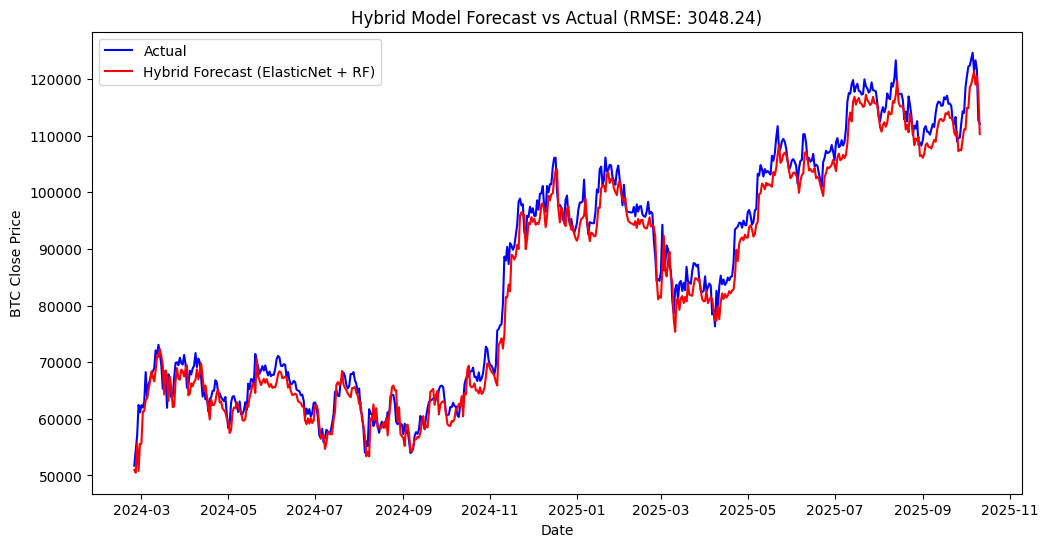

In [13]:
# YOUR CODE HERE
#Calulate RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
#Plot Actual y_test vs Predicted y_pred_hybrid
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, y_pred_hybrid, label='Hybrid Forecast (ElasticNet + RF)', color='red')
plt.title(f'Hybrid Model Forecast vs Actual (RMSE: {rmse_rf:.2f})')
plt.xlabel('Date')
plt.ylabel('BTC Close Price')
plt.legend()
plt.show()

### From the model forecast it's obivous to see that model does not struggle to capture behaviour of data afte apply detrending and and model trend using `Elasticnet model or linear regression` and train model in reseduils

## Task 7: Multi-Step Forecasting (Direct Strategy)
As discussed in Lecture 3, predicting multiple steps into the future (e.g., 3 days ahead) requires specific strategies to avoid compounding errors.

Implement the **Direct Strategy** for a 3-day ahead forecast:
1. Create a new target variable in your original dataframe: `target_lead_3` (The Close price shifted *backwards* by 3 days using `.shift(-3)`).
2. Drop the newly created NaNs.
3. Set up a new Train/Test split.
4. Train a completely separate, independent model to predict `target_lead_3` directly from today's features.

Direct Strategy - Training size: 2374, Testing size: 594


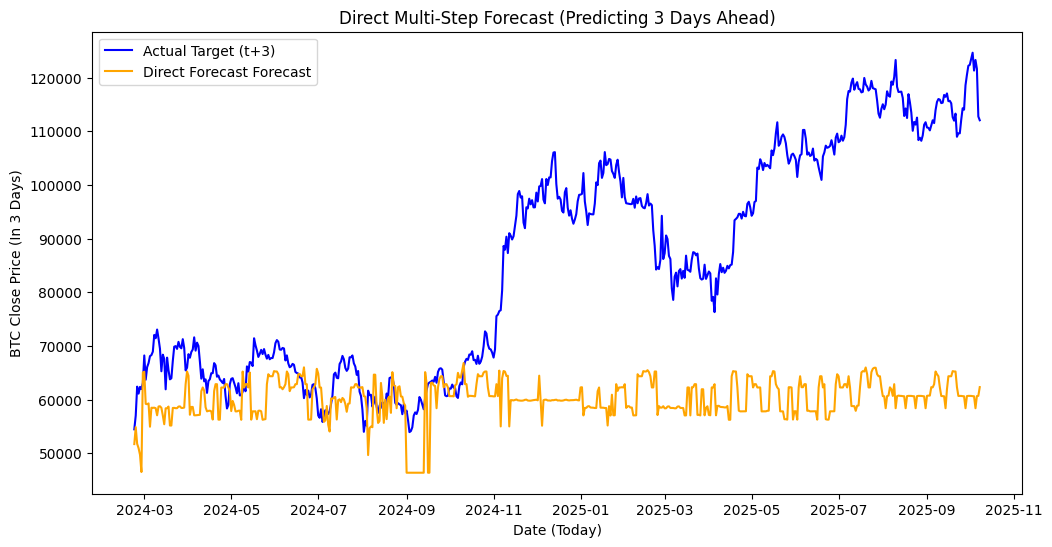

In [15]:
# YOUR CODE HERE
# 1. Create a new target variable: Close price 3 days from now
# Using shift(-3) moves future values back by 3 rows
daily_df['target_lead_3'] = daily_df['Close'].shift(-3)

# 2. Drop the newly created NaNs 
# (The very last 3 days in our dataset won't have a known target 3 days into the future)
daily_df_direct = daily_df.dropna()

# 3. Set up a new Train/Test split
# Drop both the original 'Close' and the new target from the features
X_direct = daily_df_direct.drop(columns=['Close', 'target_lead_3']) 
y_direct = daily_df_direct['target_lead_3']

# 80/20 Chronological split
split_index_direct = int(len(daily_df_direct) * 0.8)
X_train_dir = X_direct.iloc[:split_index_direct]
X_test_dir = X_direct.iloc[split_index_direct:]

y_train_dir = y_direct.iloc[:split_index_direct]
y_test_dir = y_direct.iloc[split_index_direct:]

print(f"Direct Strategy - Training size: {len(X_train_dir)}, Testing size: {len(X_test_dir)}")

# 4. Train a completely separate, independent model
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Train standard Random Forest model explicitly mapped to predict t+3
rf_direct_model = RandomForestRegressor(bootstrap=False, random_state=42)
rf_direct_model.fit(X_train_dir, y_train_dir)

# Evaluate and Plot
y_pred_direct = rf_direct_model.predict(X_test_dir)

plt.figure(figsize=(12, 6))
plt.plot(y_test_dir.index, y_test_dir.values, label='Actual Target (t+3)', color='blue')
plt.plot(y_test_dir.index, y_pred_direct, label='Direct Forecast Forecast', color='orange')
plt.title('Direct Multi-Step Forecast (Predicting 3 Days Ahead)')
plt.xlabel('Date (Today)')
plt.ylabel('BTC Close Price (In 3 Days)')
plt.legend()
plt.show()

### Solving problem

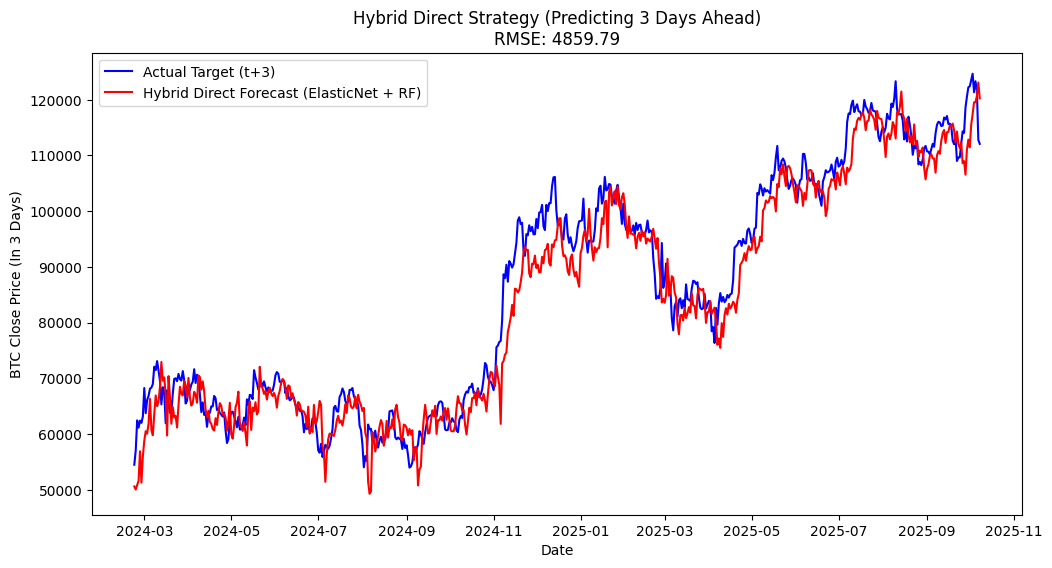

In [16]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Fit a linear model to capture the overall long-term trend mapped to t+3
trend_model_direct = ElasticNetCV(cv=5)
trend_model_direct.fit(X_train_dir, y_train_dir)

# 2. Extract the trend from the training data (Detrending)
trend_pred_train_dir = trend_model_direct.predict(X_train_dir)
y_train_detrend_dir = y_train_dir - trend_pred_train_dir

# 3. Train the Random Forest on the detrended residuals
rf_hybrid_direct = RandomForestRegressor(bootstrap=False, random_state=42)
rf_hybrid_direct.fit(X_train_dir, y_train_detrend_dir)

# 4. Predict on the test set by combining Trend + Tree Residuals (for t+3)
trend_pred_test_dir = trend_model_direct.predict(X_test_dir)
rf_residual_pred_dir = rf_hybrid_direct.predict(X_test_dir)

y_pred_hybrid_direct = trend_pred_test_dir + rf_residual_pred_dir

# Calculate RMSE to compare vs non-detrended model
rmse_hybrid_direct = np.sqrt(mean_squared_error(y_test_dir, y_pred_hybrid_direct))

# 5. Plot the hybrid model results
plt.figure(figsize=(12, 6))
plt.plot(y_test_dir.index, y_test_dir.values, label='Actual Target (t+3)', color='blue')
plt.plot(y_test_dir.index, y_pred_hybrid_direct, label='Hybrid Direct Forecast (ElasticNet + RF)', color='red')
plt.title(f'Hybrid Direct Strategy (Predicting 3 Days Ahead)\nRMSE: {rmse_hybrid_direct:.2f}')
plt.xlabel('Date')
plt.ylabel('BTC Close Price (In 3 Days)')
plt.legend()
plt.show()

## Conclusion & Key Takeaways

In this lab, we successfully transitioned from classical time series models to **Supervised Machine Learning (ML)** for forecasting. Here are the core lessons learned:

1. **Tabular Transformation**: ML models require time series data to be transformed into structured features using techniques like **Lags**, **Rolling Windows**, and **Temporal Embeddings** (e.g., month, day of week, sinusoidal features).
2. **Chronological Splitting**: We must always split time-series data chronologically. Random splitting causes **target leakage** (using future data to predict the past).
3. **The Extrapolation Problem**: Tree-based models (like Random Forest and XGBoost) are powerful at finding complex patterns but have a critical flaw: **they cannot predict values outside the range of their training data**. They fail to capture new upward or downward trends.
4. **Hybrid Modeling (The Solution)**: By combining models, we get the best of both worlds. We use a **Linear Model** (ElasticNet, Linear Regression) to capture the overall infinite trend, and a **Tree Model** to predict the non-linear fluctuations (residuals) around that trend.
5. **Direct Multi-Step Strategy**: To forecast multiple days into the future without letting errors compound over time, the **Direct Strategy** (training a unique model to predict exactly $T+N$ steps ahead) is highly effective. 